In [21]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [22]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage, ChatMessage

In [23]:
class AgentState(TypedDict):
    task: str
    plan: str
    draft: str
    critique: str
    content: List[str]
    revision_number: int
    max_revisions: int

In [24]:
PLAN_PROMPT = """You are an expert report writer tasked with writing a high level outline of an report. \
Write such an outline for the user provided topic. Give an outline of the report along with any relevant notes \
or instructions for the sections."""

RESEARCH_PLAN_PROMPT = """You are a researcher charged with providing information that can \
be used when writing the following report. Generate a list of search queries that will gather \
any relevant information. Only generate 3 queries max."""

WRITER_PROMPT = """You are an report assistant tasked with writing excellent a one page report.\
Generate the best report possible for the user's request and the initial outline. \
If the user provides critique, respond with a revised version of your previous attempts. \
Utilize all the information below as needed: 

------

{content}"""

REFLECTION_PROMPT = """You are a teacher grading an report submission. \
Generate critique and recommendations for the user's submission. \
Provide detailed recommendations, including requests for length, depth, style, etc."""

RESEARCH_CRITIQUE_PROMPT = """You are a researcher charged with providing information that can \
be used when making any requested revisions (as outlined below). \
Generate a list of search queries that will gather any relevant information. Only generate 3 queries max."""


In [26]:
# from langchain_groq import ChatGroq

# llm = ChatGroq(
#     model="llama-3.3-70b-versatile",
#     temperature=0
# )

from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",
)


In [27]:
from langchain_core.pydantic_v1 import BaseModel

class Queries(BaseModel):
    queries: List[str]


In [28]:
from tavily import TavilyClient
import os 
tavily = TavilyClient()

In [ ]:
def planNode(state: AgentState):
    messages = [
        SystemMessage(content=PLAN_PROMPT),
        HumanMessage(content=state['task'])
    ]
    response= llm.invoke(messages)
    return {"plan": response.content}



In [75]:
queries = llm.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_PLAN_PROMPT),
        HumanMessage(content="AI Boon Or Bane. Summary, Content, Introduction, Conclusion")
    ])

print(queries)

queries=['AI benefits and risks summary', 'introduction to the debate on artificial intelligence', 'conclusion on the impact of artificial intelligence']


In [78]:
print(type(queries))
print(queries.queries)

for i in queries.queries:
    print(i)

<class '__main__.Queries'>
['AI benefits and risks summary', 'introduction to the debate on artificial intelligence', 'conclusion on the impact of artificial intelligence']
AI benefits and risks summary
introduction to the debate on artificial intelligence
conclusion on the impact of artificial intelligence


In [81]:
content = []
for q in queries.queries:
    print(type(q))
    response = tavily.search(query=q, max_results=3)
    for r in response['results']:
        content.append(r['content'])

<class 'str'>
<class 'str'>
<class 'str'>


In [82]:
print(content)

['From SIRI to self-driving cars, artificial intelligence (AI) is progressing rapidly. From SIRI to self-driving cars, artificial intelligence (AI) is progressing rapidly. The AI is programmed to do something devastating:\xa0Autonomous weapons are artificial intelligence systems that are programmed to kill. Slaughterbots,\xa0also called “lethal autonomous weapons systems” or “killer robots”,\xa0are\xa0weapons\xa0systems that use artificial intelligence (AI) to identify, select, and kill human targets without human\xa0intervention. There are fascinating controversies where the world’s leading experts disagree, such as: AI’s future impact on the job market; if/when human-level AI will be developed; whether this will lead to an intelligence explosion; and whether this is something we should welcome or fear. Stanford One Hundred Year Study on Artificial Intelligence (AI100)', 'We’ve all seen the headlines about AI, both the good and bad. In this article, we’ll discuss the major benefits an

In [83]:
def researchNode(state: AgentState):
    queries = llm.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_PLAN_PROMPT),
        HumanMessage(content=state['task'])
    ])
    
    content = state.get('content', [])

    for q in queries.queries:
        response = tavily.search(query=q, max_results=3)
        for r in response['results']:
            content.append(r['content'])
        
    return {"content": content}


In [84]:
def generationNode(state: AgentState):
    content="\n\n".join(state['content'] or [])
    
    user_message = HumanMessage(content=f"{state['task']} \n\n Here is my plan {state['plan']}")
    
    message = [
        SystemMessage(content=WRITER_PROMPT.format(content=content)),
        user_message
    ]
    
    response = llm.invoke(message)
    
    return {
        "draft": response.content,
        "revision_number": state.get("revision_number", 1) + 1
    }

In [85]:
def reflectionNode(state: AgentState):
    messages= [
        SystemMessage(content=REFLECTION_PROMPT),
        HumanMessage(content=state["draft"])
    ]
    
    response = llm.invoke(messages)
    
    return {"critique": response.content}

In [94]:
def researchCritiqueNode(state: AgentState):
    queries = llm.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_CRITIQUE_PROMPT),
        HumanMessage(content=state['critique'])
    ])
    
    content = state['content'] or []
    for q in queries.queries:
        response = tavily.search(query=q, max_results=2)
        for r in response.get('results', []):
            content.append(r['content'])
            
    return {"content": content}    

In [95]:
def toContinue(state):
    if state["revision_number"] > state["max_revisions"]:
        return END
    
    return "reflect"

In [96]:
bulider = StateGraph(AgentState)

bulider.add_node("planner", planNode)
bulider.add_node("research_plan", researchNode)
bulider.add_node("generate", generationNode)
bulider.add_node("reflect", reflectionNode)
bulider.add_node("research_critique", researchCritiqueNode)

In [97]:
bulider.add_conditional_edges(
    "generate",
    toContinue,
    {END: END, "reflect": "reflect"}
)

In [98]:
bulider.set_entry_point("planner")
bulider.add_edge("planner", "research_plan")
bulider.add_edge("research_plan", "generate")
bulider.add_edge("reflect", "research_critique")
bulider.add_edge("research_critique", "generate")

In [99]:
from langgraph.checkpoint.memory import MemorySaver

graph = bulider.compile(checkpointer=MemorySaver())

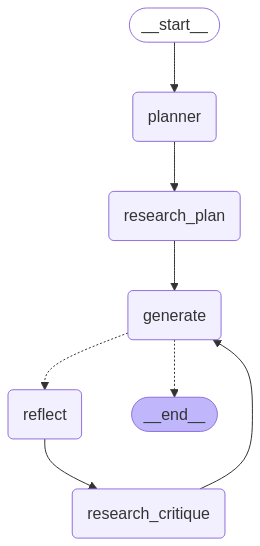

In [100]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [106]:
import pprint

thread = {"configurable": {"thread_id": "001"}}

complete_response = ""

for s in graph.stream(
    {"task": "AI Boon or Bane", "max_revisions": 2, "revision_number": 1}, 
    thread
):
    pprint.pprint(s)


{'planner': {'plan': "Okay, here's a high-level outline for a report exploring "
                     'whether AI is a boon or a bane, along with notes for '
                     'each section.\n'
                     '\n'
                     '**Report Title: AI: Boon or Bane? Navigating the '
                     'Promises and Perils of Artificial Intelligence**\n'
                     '\n'
                     '**I. Executive Summary**\n'
                     '\n'
                     "*   **Content:** A concise overview of the report's "
                     'findings. State the core argument (e.g., AI presents '
                     'both significant opportunities and risks, and its '
                     'ultimate impact depends on responsible development and '
                     'deployment). Highlight key benefits and potential '
                     'dangers discussed in the report.\n'
                     '*   **Notes:** Keep it brief (no more than half a page). '
         

In [ ]:
print(complete_response)